In [31]:
import pandas as pd
import os
from matplotlib import pyplot as plt
import numpy as np

from tueplots import bundles
plt.rcParams.update(bundles.beamer_moml())
plt.rcParams.update({'font.sans-serif': 'DejaVu Sans', 'figure.dpi': 200})

In [6]:
df = pd.read_csv(os.path.join("..", "process_outputs", "baseline_results.csv"))
df

,environment,approach,seed,value
0,tiger,hardcoded,0,0.937465
1,tiger,hardcoded,1,0.926540
2,tiger,hardcoded,2,0.919124
3,tiger,hardcoded,3,0.915539
4,tiger,hardcoded,4,0.912385
...,...,...,...,...
275,four_rooms,random,8,0.000000
276,four_rooms,random,9,0.000000
277,lava,hardcoded,1,0.069514
278,lava,hardcoded,4,0.124062


In [34]:
df_plot = df.groupby(['environment', 'approach'])['value'].agg(['mean', 'std']).reset_index()

# Get the hardcoded mean per environment
hardcoded_means = (
    df_plot[df_plot['approach'] == 'hardcoded']
    .set_index('environment')['value']        # Series: env -> mean(hardcoded)
)

# Get a column with the env-specific hardcoded mean
df_plot['hardcoded_mean'] = df_plot['environment'].map(hardcoded_means)

# Normalize each mean by the hardcoded mean of that environment
g['value_norm'] = g['value'] / g['hardcoded_mean']
g

KeyError: 'value'

<BarContainer object of 4 artists>

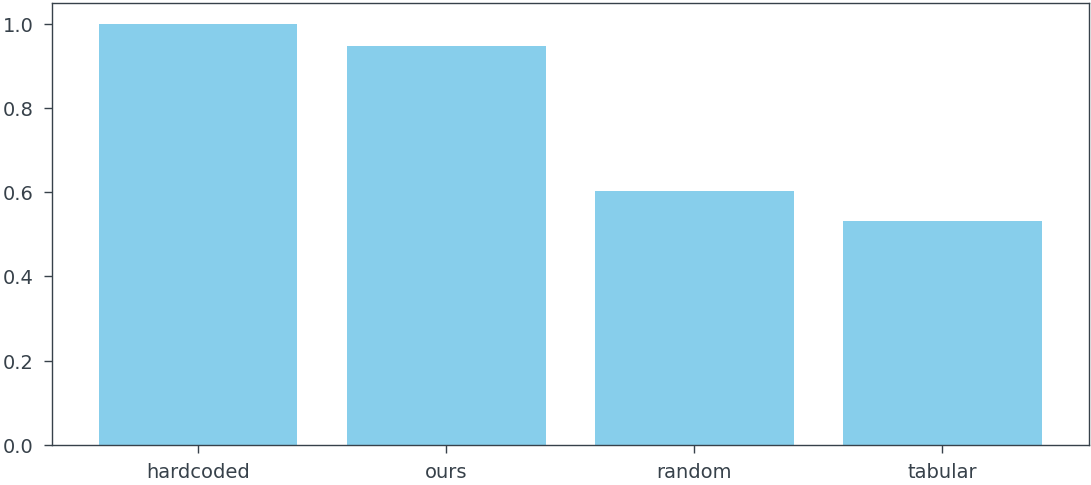

In [29]:
fig, ax = plt.subplots()

ax.bar(df_plot[df_plot['environment'] == 'tiger']['approach'], df_plot[df_plot['environment'] == 'tiger']['value_norm'], color='skyblue')

KeyError: 'std'

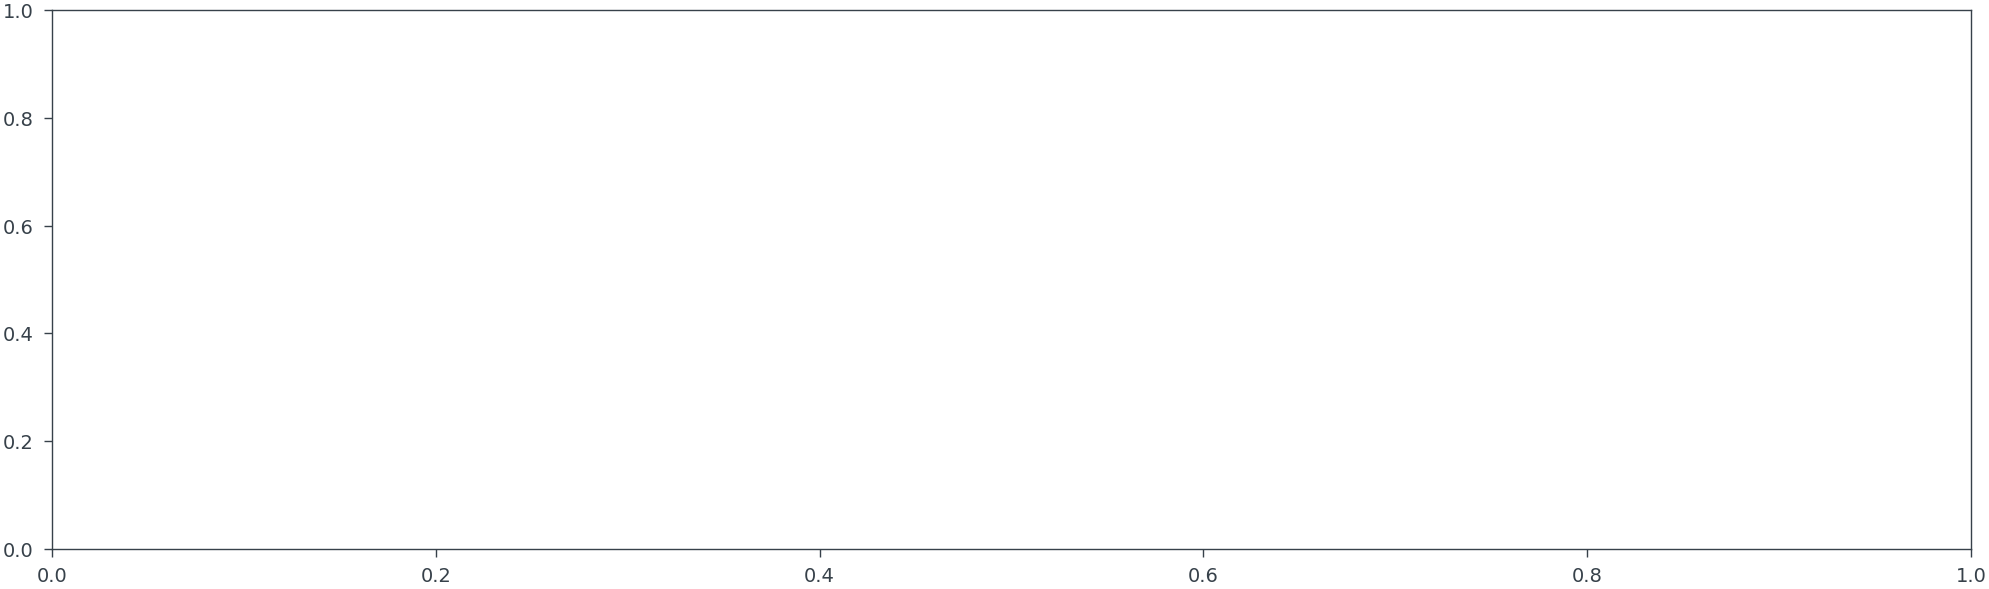

In [33]:
envs = df_plot["environment"].unique()
approaches = df_plot["approach"].unique()

x = np.arange(len(envs))          # one base x for each environment
width = 0.1                       # bar width (tune for #approaches)

fig, ax = plt.subplots(figsize=(10, 3))

for i, approach in enumerate(approaches):
    data = df_plot[df_plot["approach"] == approach]
    means = data["value_norm"].values
    stds = data["std"].values

    # shift each approach within the environment group
    ax.bar(
        x + (i - len(approaches)/2) * width + width/2,
        means,
        width,
        yerr=stds,
        label=approach,
        capsize=3,
    )

ax.set_xticks(x)
ax.set_xticklabels(envs)
ax.set_ylabel("Normalised Discounted Reward")
ax.set_title("Episode Reward Across Environments & Approaches")
ax.legend(ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.1))